# 01 - Sentiment Analysis
**QSS 20 Final Project | Olivia Tak**

This notebook runs VADER sentiment analysis on video titles to generate
arousal scores and sentiment labels for each video.

## Imports

In [2]:
import sys
!{sys.executable} -m pip install vaderSentiment


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

## Load cleaned data

In [4]:
# load the cleaned dataset from previous notebook
df = pd.read_csv('../data/df_2023_clean.csv')
print(df.shape)

(12176, 21)


## Run VADER on video titles

In [7]:
# initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# apply VADER to each title and extract compound score
df['compound'] = df['title'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# arousal score = absolute value of compound (high positive OR negative = high arousal)
df['arousal_score'] = df['compound'].abs()

# sentiment label based on compound score thresholds
df['sentiment_label'] = df['compound'].apply(lambda x: 'positive' if x > 0.05 
                                              else ('negative' if x < -0.05 
                                              else 'neutral'))

print(df[['title', 'compound', 'arousal_score', 'sentiment_label']].head(10))

                                               title  compound  arousal_score  \
0  Peach Bowl: Ohio State Buckeyes vs. Georgia Bu...    0.0000         0.0000   
1                              Tom MacDonald - Ghost   -0.3182         0.3182   
2  Ñengo Flow, Bad Bunny - Gato de Noche ( Video ...   -0.5423         0.5423   
3  Seattle weather conditions: Ongoing power outa...    0.0000         0.0000   
4         Honda’s $225 Million Mistake – Rune Review   -0.3400         0.3400   
5                         i became an italian farmer    0.0000         0.0000   
6             What Dan and Phil Text Each Other 2022    0.0000         0.0000   
7  It’s Beginning To Look A Lot Like Christmas (c...    0.3612         0.3612   
8        That '90s Show | Official Trailer | Netflix    0.0000         0.0000   
9          20 Things You Didn't Know About The NBA..    0.0000         0.0000   

  sentiment_label  
0         neutral  
1        negative  
2        negative  
3         neutral  
4       

In [8]:
# check distribution of sentiment labels
print(df['sentiment_label'].value_counts())
print(df['arousal_score'].describe().round(3))

sentiment_label
neutral     6686
positive    2775
negative    2715
Name: count, dtype: int64
count    12176.000
mean         0.209
std          0.264
min          0.000
25%          0.000
50%          0.000
75%          0.440
max          0.954
Name: arousal_score, dtype: float64


## Starter visualization: arousal score vs views


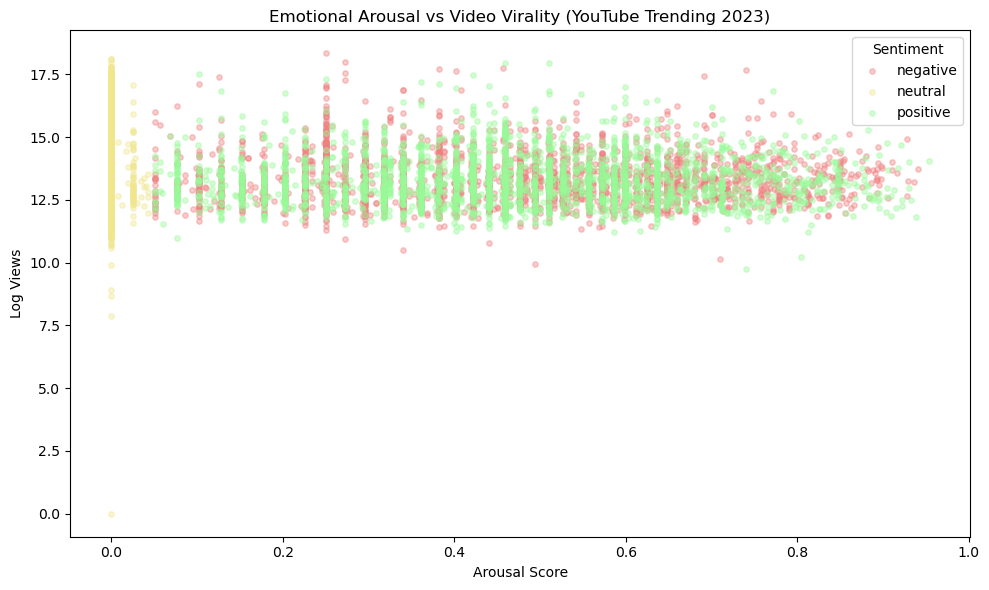

In [13]:
# create scatter plot of arousal score vs log views colored by sentiment label
fig, ax = plt.subplots(figsize=(10, 6))

# define colors for each sentiment label
colors = {'positive': 'palegreen', 'negative': 'lightcoral', 'neutral': 'khaki'}

# plot each sentiment group separately so we can add a legend
for label, group in df.groupby('sentiment_label'):
    ax.scatter(group['arousal_score'], 
               group['log_views'],
               c=colors[label],
               label=label,
               alpha=0.4,
               s=15)

ax.set_xlabel('Arousal Score')
ax.set_ylabel('Log Views')
ax.set_title('Emotional Arousal vs Video Virality (YouTube Trending 2023)')
ax.legend(title='Sentiment')

plt.tight_layout()
plt.savefig('../output/fig1_arousal_vs_views.png', dpi=150)
plt.show()

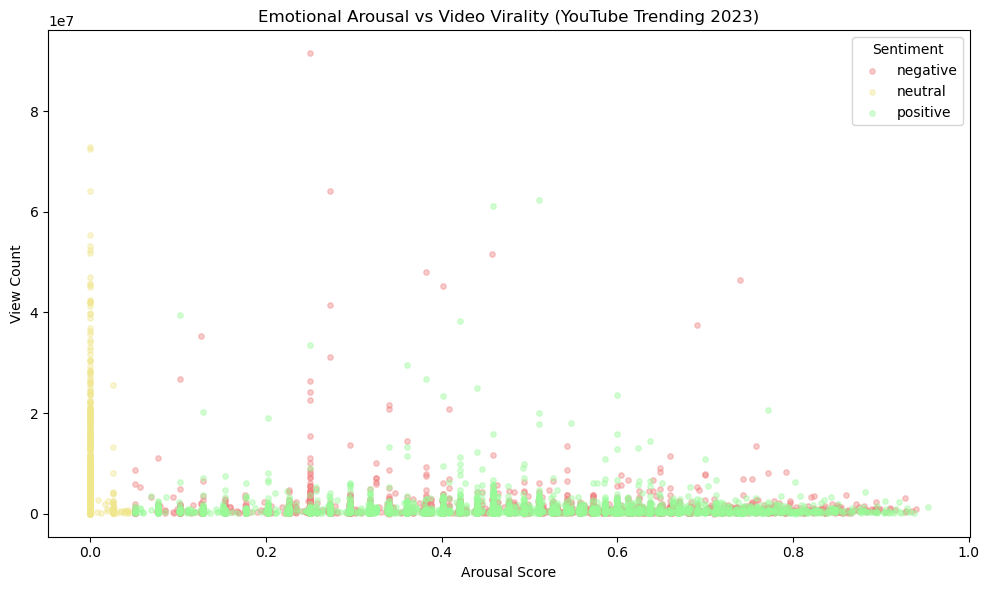

In [14]:
# quick scatter plot with raw view count to see what it looks like
fig, ax = plt.subplots(figsize=(10, 6))

for label, group in df.groupby('sentiment_label'):
    ax.scatter(group['arousal_score'], 
               group['view_count'],
               c=colors[label],
               label=label,
               alpha=0.4,
               s=15)

ax.set_xlabel('Arousal Score')
ax.set_ylabel('View Count')
ax.set_title('Emotional Arousal vs Video Virality (YouTube Trending 2023)')
ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [10]:
# save dataframe with sentiment scores for use in future notebooks
df.to_csv('../data/df_2023_sentiment.csv', index=False)
print("Saved successfully")

Saved successfully


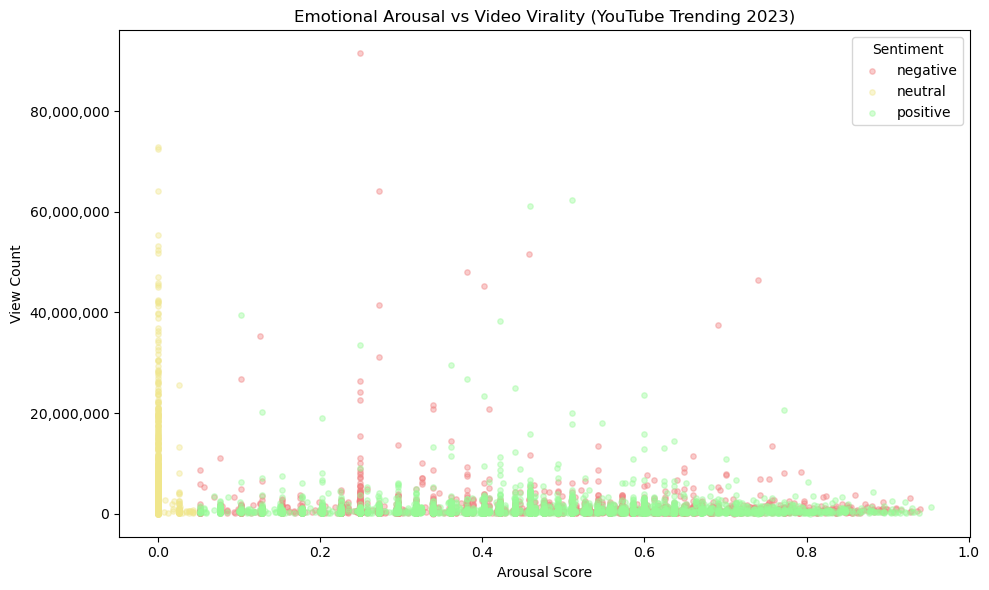

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, group in df.groupby('sentiment_label'):
    ax.scatter(group['arousal_score'], 
               group['view_count'],
               c=colors[label],
               label=label,
               alpha=0.4,
               s=15)

ax.set_xlabel('Arousal Score')
ax.set_ylabel('View Count')
ax.set_title('Emotional Arousal vs Video Virality (YouTube Trending 2023)')
ax.legend(title='Sentiment')

# format y axis to show full numbers instead of scientific notation
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.savefig('../output/fig1_arousal_vs_views.png', dpi=150)
plt.show()

## Exploratory visualization: average view count by category


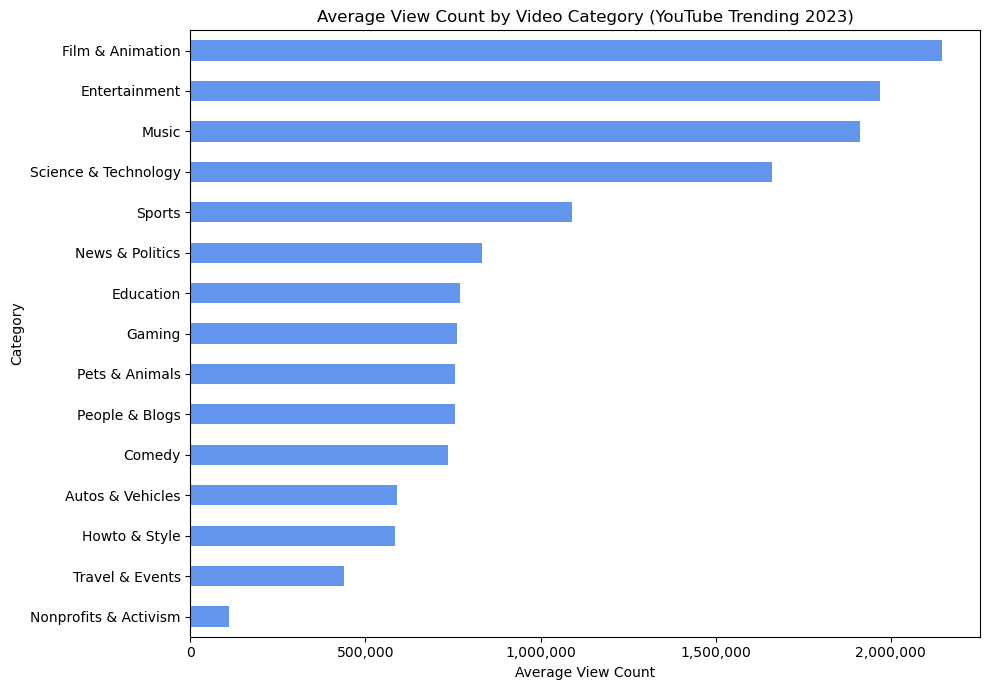

In [5]:
# calculate average view count per category
category_views = (df.groupby('category')['view_count']
                  .mean()
                  .sort_values(ascending=True))

# plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))

category_views.plot(kind='barh', ax=ax, color='cornflowerblue')

ax.set_xlabel('Average View Count')
ax.set_ylabel('Category')
ax.set_title('Average View Count by Video Category (YouTube Trending 2023)')

# format x axis to show full numbers instead of scientific notation
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.savefig('../output/fig2_views_by_category.png', dpi=150)
plt.show()

## Exploratory visualization: average arousal score by category

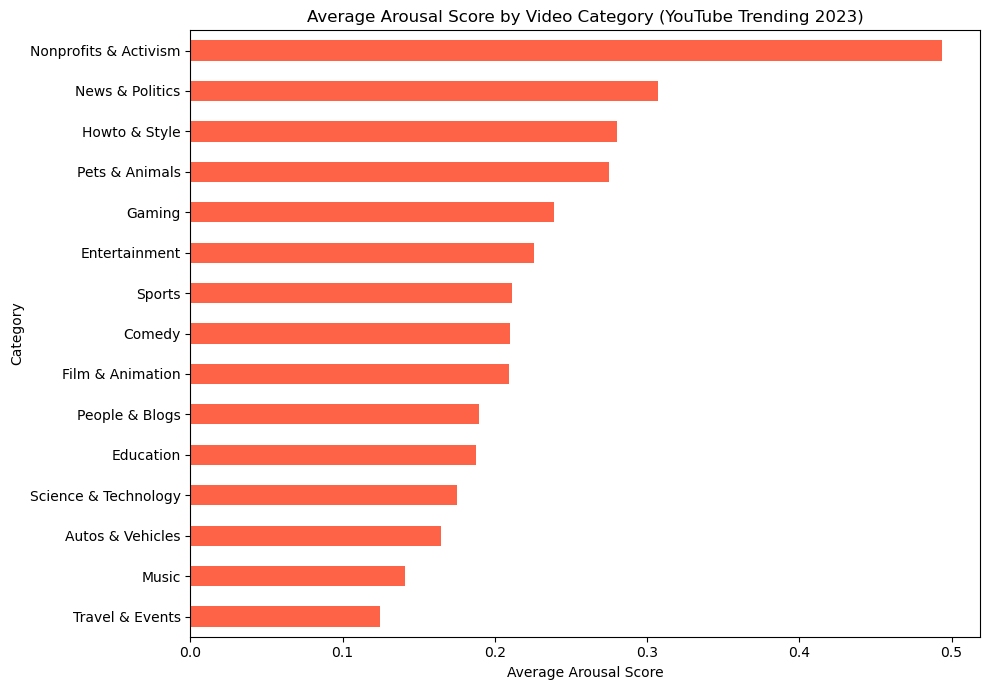

In [9]:
# calculate average arousal score per category
category_arousal = (df.groupby('category')['arousal_score']
                    .mean()
                    .sort_values(ascending=True))

# plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))

category_arousal.plot(kind='barh', ax=ax, color='tomato')

ax.set_xlabel('Average Arousal Score')
ax.set_ylabel('Category')
ax.set_title('Average Arousal Score by Video Category (YouTube Trending 2023)')

plt.tight_layout()
plt.savefig('../output/fig3_arousal_by_category.png', dpi=150)
plt.show()

## Exploratory visualization: top 15 videos by days trending

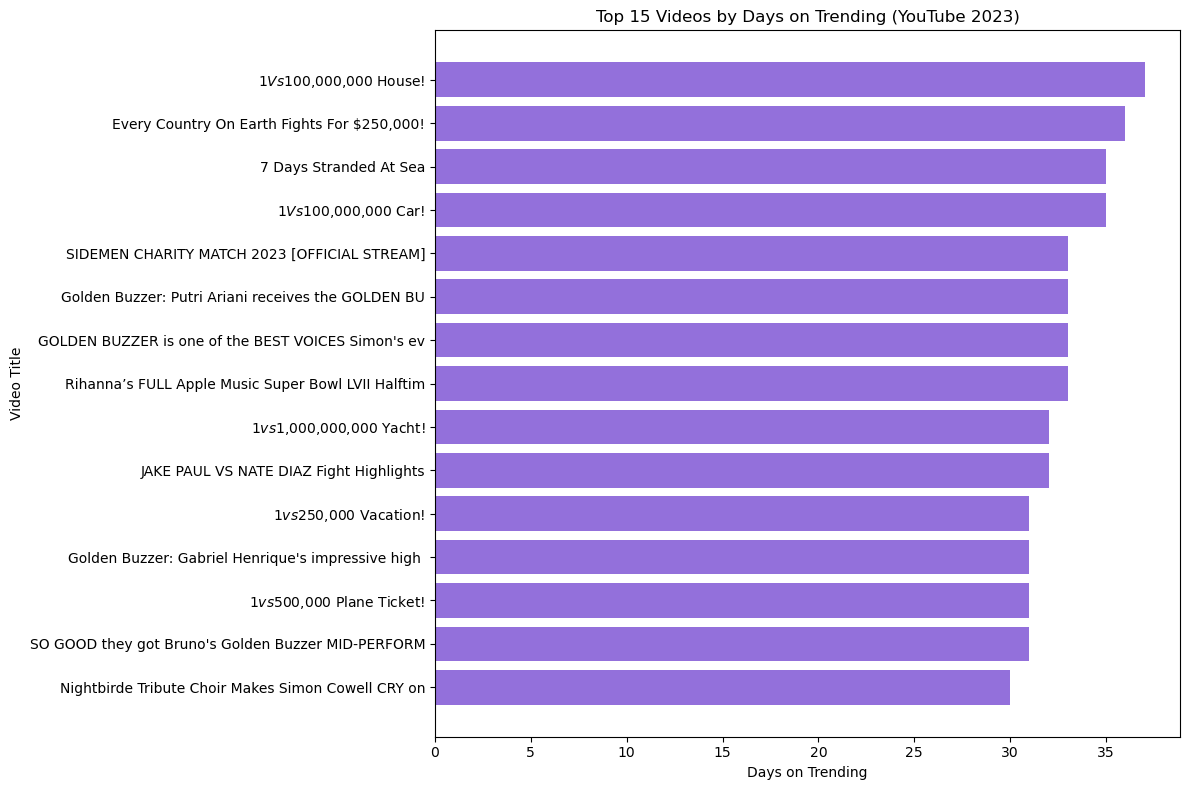

In [10]:
# get top 15 videos by days trending
top_trending = (df[['title', 'days_trending']]
                .sort_values('days_trending', ascending=True)
                .tail(15))

# shorten long titles so they fit on the chart
top_trending['title'] = top_trending['title'].str[:50]

# plot horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(top_trending['title'], top_trending['days_trending'], color='mediumpurple')

ax.set_xlabel('Days on Trending')
ax.set_ylabel('Video Title')
ax.set_title('Top 15 Videos by Days on Trending (YouTube 2023)')

plt.tight_layout()
plt.savefig('../output/fig4_top_trending.png', dpi=150)
plt.show()